In [13]:
#python
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# model architechture 
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB

In [14]:
#data load
dfTrue = pd.read_csv('True.csv')
dfFake = pd.read_csv('Fake.csv')
dfTrue['NewsType'] = 1
dfFake['NewsType'] = 0

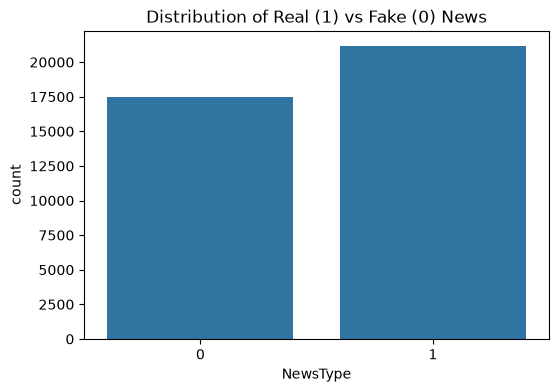

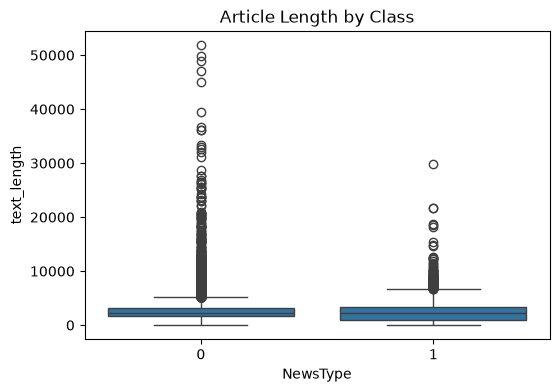

In [15]:
    #combination and removal of duplicate data
    data = pd.concat([dfTrue,dfFake])
    data = data.drop_duplicates(subset=['text'])
    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    data['original_text'] = data['title'] + " " + data['text']
    data = data[['original_text', 'NewsType']]
    
    # performing EDA on the dataset 
    plt.figure(figsize=(6, 4))
    sns.countplot(x='NewsType', data=data)
    plt.title("Distribution of Real (1) vs Fake (0) News")
    plt.show()
    
    data['text_length'] = data['original_text'].apply(len)
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='NewsType', y='text_length', data=data)
    plt.title("Article Length by Class")
    plt.show()

In [16]:
# text preprocessing functions
def remove_tags(text):
    text = str(text)
    clean_text = re.sub(re.compile('<.*?>'),'',text)
    return clean_text

def remove_urls(text):
    text = str(text)
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'',text)

exclude = string.punctuation
def remove_punc(text):
    return text.translate(str.maketrans('','',exclude))
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])
def remove_publisher_dateline(text):
    text = str(text)
    clean_text = re.sub(r'^.*?\(Reuters\)\s*-\s*', '', text, flags=re.IGNORECASE)
    clean_text = re.sub(r'\breuters\b', '', clean_text, flags=re.IGNORECASE)
    return clean_text

#applying cleaning pipeline 
data['original_text']= data['original_text'].apply(remove_tags)
data['original_text'] = data['original_text'].apply(lambda x: x.lower())
data['original_text'] = data['original_text'].apply(remove_urls)
data['original_text'] = data['original_text'].apply(remove_publisher_dateline) # N
data['original_text'] = data['original_text'].apply(remove_punc)
data['original_text'] = data['original_text'].apply(remove_stopwords)

In [17]:
# data split for the ml model training 
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data['original_text'],
    data['NewsType'],
    test_size=0.2,
    random_state=42,
    stratify=data['NewsType']
)

# tf-idf vectorization 
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)
print("Text representation complete! Vectorized matrix shape:", X_train.shape)

Text representation complete! Vectorized matrix shape: (30916, 5000)


Evaluating Models with 5-Fold Cross Validation & Hold-Out Test Set...
-----------------------------------------------------------------


/Users/ravish/NumPy/.venv/lib/python3.14/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/Users/ravish/NumPy/.venv/lib/python3.14/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/Users/ravish/NumPy/.venv/lib/python3.14/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
 

model comparison results:
                    Architecture  5-Fold CV Accuracy (%)  Test Accuracy (%)
0  Passive Aggressive Classifier                   98.60              98.58
1            Logistic Regression                   98.22              98.28
2                  Random Forest                   97.80              98.20
3        Multinomial Naive Bayes                   93.69              93.54
-----------------------------------------------------------------

 Detailed Classification Report for Random Forest:
               precision    recall  f1-score   support

Fake News (0)       0.99      0.97      0.98      3491
Real News (1)       0.98      0.99      0.98      4239

     accuracy                           0.98      7730
    macro avg       0.98      0.98      0.98      7730
 weighted avg       0.98      0.98      0.98      7730



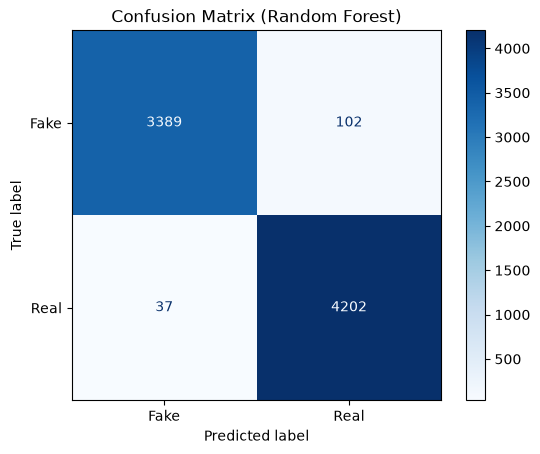

Input Text: 'The Federal Reserve announced a quarter-point interest rate hike on Wednesday following the monthly committee meeting in Washington.'

Probability Breakdown:
• Fake News Probability: 31.00%
• Real News Probability: 69.00%
----------------------------------------
Verdict: REAL NEWS



In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Passive Aggressive Classifier": PassiveAggressiveClassifier(max_iter=50, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

trained_models = {}
results = []

print("Evaluating Models with 5-Fold Cross Validation & Hold-Out Test Set...")
print("-" * 65) 

for model_name, model in models.items():
    # 5-gfold CV on training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()*100
    
    # train
    model.fit(X_train, y_train)
    trained_models[model_name] = model 
    # predict
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test,y_pred)*100
    # evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results.append({
        "Architecture": model_name,
        "5-Fold CV Accuracy (%)": round(cv_mean, 2),
        "Test Accuracy (%)": round(test_accuracy, 2)
    })

comparison_df = pd.DataFrame(results).sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)

print("model comparison results:")
print(comparison_df)
print("-" * 65)

selected_model_name = "Random Forest"
selected_model = trained_models[selected_model_name]
y_pred_selected = selected_model.predict(X_test)

print(f"\n Detailed Classification Report for {selected_model_name}:")
print(classification_report(y_test, y_pred_selected, target_names=["Fake News (0)", "Real News (1)"]))

cm = confusion_matrix(y_test, y_pred_selected)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix ({selected_model_name})")
plt.show()

def predict_custom_news(custom_text):
    cleaned_text = remove_tags(custom_text)
    cleaned_text = cleaned_text.lower() 
    cleaned_text = remove_urls(cleaned_text)
    cleaned_text = remove_publisher_dateline(cleaned_text)
    cleaned_text = remove_punc(cleaned_text)
    cleaned_text = remove_stopwords(cleaned_text)
    

    vectorized_text = tfidf.transform([cleaned_text])

    prediction = selected_model.predict(vectorized_text)[0]
    print(f"Input Text: '{custom_text}'\n")
    if hasattr(selected_model, "predict_proba"):
        probabilities = selected_model.predict_proba(vectorized_text)[0]
        print("Probability Breakdown:")
        print(f"• Fake News Probability: {probabilities[0] * 100:.2f}%")
        print(f"• Real News Probability: {probabilities[1] * 100:.2f}%")
        print("-" * 40)
    
    verdict = "REAL NEWS" if prediction == 1 else "FAKE NEWS"
    print(f"Verdict: {verdict}\n")

my_news = "The Federal Reserve announced a quarter-point interest rate hike on Wednesday following the monthly committee meeting in Washington."
predict_custom_news(my_news)